# RED NEURONAL RECURRENTE PARA PREDECIR EL PRECIO DE LA BOLSA DE VALORES

# 1 - IMPORTAMOS LIBRERIAS

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

# 2 - CARGAMOS DATASET PARA PRECIOS DE COCA COLA COMPANY(KO)

In [2]:
# Descargar datos históricos de KO (Coca-Cola) desde Yahoo Finance
symbol = "KO"
data = yf.download(symbol, start="2026-01-01", end="2026-05-30")

/tmp/ipykernel_899/1213841110.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start="2026-01-01", end="2026-05-30")
[*********************100%***********************]  1 of 1 completed


In [3]:
data

Price,Close,High,Low,Open,Volume
Ticker,KO,KO,KO,KO,KO
Date,,,,,
2026-01-02,68.647980,69.392858,68.508936,69.372990,12151300
2026-01-05,67.476036,68.449339,67.456168,68.449339,21186600
2026-01-06,67.376717,67.783920,67.128424,67.545561,21019900
2026-01-07,67.078766,67.605145,66.810605,67.525690,20223400
2026-01-08,68.896271,68.985652,66.989377,67.078766,19237000
...,...,...,...,...,...
2026-05-20,81.550003,82.400002,81.519997,82.169998,16999700
2026-05-21,81.169998,81.800003,80.720001,81.790001,15708400


In [4]:
data.columns

MultiIndex([( 'Close', 'KO'),
            (  'High', 'KO'),
            (   'Low', 'KO'),
            (  'Open', 'KO'),
            ('Volume', 'KO')],
           names=['Price', 'Ticker'])

## 3 - RENOMBRAMOS LAS COLUMNAS

In [5]:
# Renombrar las columnas eliminando el MultiIndex y aplicando snake_case
data.columns = [f"{col[0].lower()}_{col[1].lower()}" for col in data.columns]

# Mostrar las nuevas columnas
print(data.head())

             close_ko    high_ko     low_ko    open_ko  volume_ko
Date                                                             
2026-01-02  68.647980  69.392858  68.508936  69.372990   12151300
2026-01-05  67.476036  68.449339  67.456168  68.449339   21186600
2026-01-06  67.376717  67.783920  67.128424  67.545561   21019900
2026-01-07  67.078766  67.605145  66.810605  67.525690   20223400
2026-01-08  68.896271  68.985652  66.989377  67.078766   19237000


## 4 - MODIFICAMOS EL DATASET PARA TRABAJAR SOLO CON EL CLOSE_KO

In [6]:
df = data[['close_ko']]
df = df.rename(columns={'close_ko': 'close'})

In [7]:
df

,close
Date,
2026-01-02,68.647980
2026-01-05,67.476036
2026-01-06,67.376717
2026-01-07,67.078766
2026-01-08,68.896271
...,...
2026-05-20,81.550003
2026-05-21,81.169998
2026-05-22,81.480003


## ESCALAMOS LOS DATOS

In [8]:
# Normalización de datos
scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = scaler.fit_transform(df)
df_scaled

array([[0.10573339],
       [0.02676801],
       [0.02007588],
       [0.        ],
       [0.12246321],
       [0.19875184],
       [0.19808253],
       [0.24760316],
       [0.26098742],
       [0.19674441],
       [0.19406766],
       [0.2817321 ],
       [0.29913123],
       [0.28976286],
       [0.35735142],
       [0.33593691],
       [0.40218787],
       [0.36939654],
       [0.39415711],
       [0.48650624],
       [0.52130501],
       [0.62569926],
       [0.65648213],
       [0.7341094 ],
       [0.76890766],
       [0.69797303],
       [0.62034576],
       [0.74013222],
       [0.76690022],
       [0.74548572],
       [0.80437471],
       [0.79969053],
       [0.76087741],
       [0.82311247],
       [0.87129447],
       [0.88200198],
       [0.86527217],
       [0.86727961],
       [0.93821423],
       [0.84854236],
       [0.78965234],
       [0.70667208],
       [0.63506814],
       [0.63573746],
       [0.68659672],
       [0.6919497 ],
       [0.67521989],
       [0.673

## 5 - CREAMOS SERIES TEMPORALES(SECUENCIAS)

In [9]:
def create_sequences(data, seq_length):
    sequences, labels = [], []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])
        labels.append(data[i+seq_length])
    return np.array(sequences), np.array(labels)

In [10]:
# Definir la longitud de la secuencia (días pasados usados para predecir)
SEQ_LENGTH = 7  # 7 días de datos para predecir el siguiente
X, y = create_sequences(df_scaled, SEQ_LENGTH)

## 6 -  DIVIDIMOS DATASET EN ENTRENAMIENTO Y PRUEBA

In [11]:
from sklearn.model_selection import train_test_split

# Dividir en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 7 - CREAMOS RED NEURONAL RECURRENTE

In [12]:
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(50, return_sequences=True, input_shape=(SEQ_LENGTH, 1)),
    tf.keras.layers.LSTM(50, return_sequences=False),
    tf.keras.layers.Dense(25, activation="relu"),
    tf.keras.layers.Dense(1)
])

# Compilar el modelo
model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
history = model.fit(X_train, y_train, epochs=100, batch_size=128, validation_data=(X_test, y_test))

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.5241 - val_loss: 0.4252
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.4719 - val_loss: 0.3922
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.4362 - val_loss: 0.3620
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.4034 - val_loss: 0.3344
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.3735 - val_loss: 0.3051
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.3418 - val_loss: 0.2726
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.3064 - val_loss: 0.2395
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.2703 - val_loss: 0.2058
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.2335 - val_loss: 0.1715
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.1959 - val_loss: 0.1374
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.1584 - val_loss: 0.1053
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.1229 - val_loss: 

# 8 - CREAMOS GRAFICO DE PREDICCIONES

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


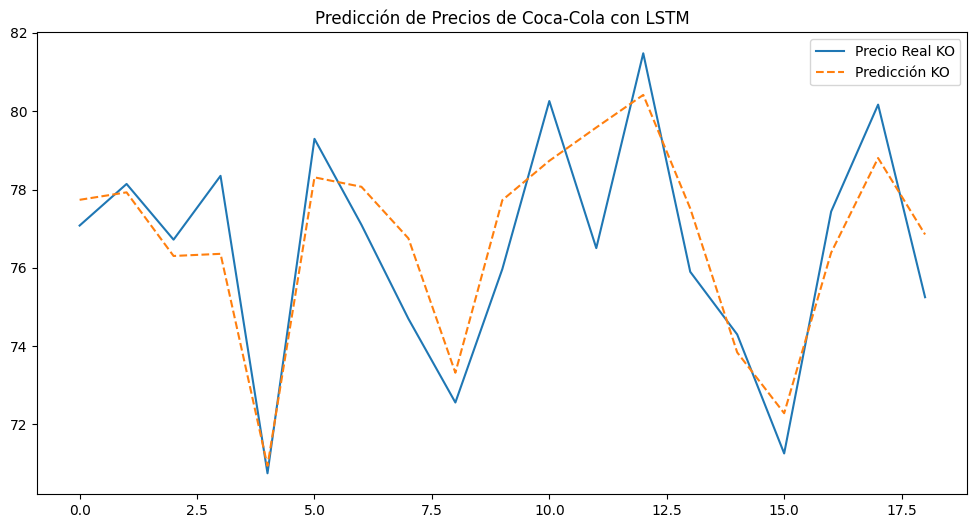

In [14]:
# Predicciones
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

# Invertir la escala de los valores reales
real_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

# Visualizar los resultados
plt.figure(figsize=(12,6))
plt.plot(real_prices, label="Precio Real KO")
plt.plot(predictions, label="Predicción KO", linestyle="dashed")
plt.legend()
plt.title("Predicción de Precios de Coca-Cola con LSTM")
plt.show()

## 9 - REALIZAMOS PREDICCIÓN PARA LOS SIGUIENTES 30 DIAS

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/

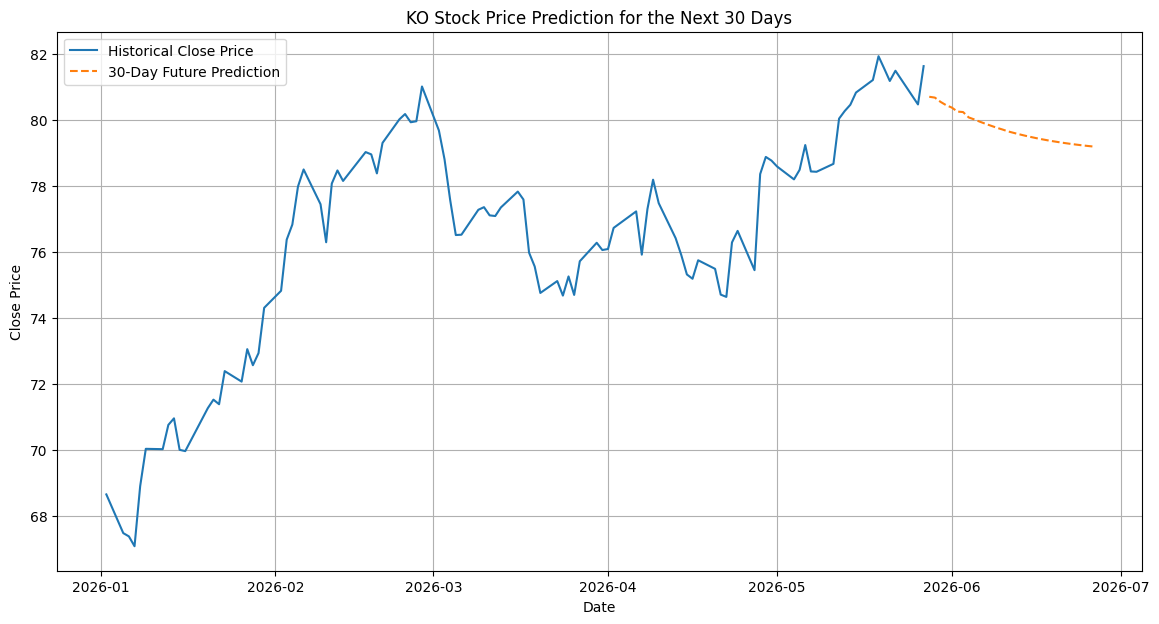

In [15]:
last_sequence = df_scaled[-SEQ_LENGTH:]
future_predictions = []

# Predict future prices
current_sequence = last_sequence.reshape(1, SEQ_LENGTH, 1)

for _ in range(30): # Predict for the next 30 days
    next_day_prediction = model.predict(current_sequence)[0]
    future_predictions.append(next_day_prediction)
    # Update the sequence: remove the first element and add the new prediction
    current_sequence = np.append(current_sequence[:, 1:, :], [[next_day_prediction]], axis=1)

# Inverse transform predictions
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Generate future dates
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date, periods=31, freq='D')[1:] # Start from the day after the last available data

# Create a DataFrame for historical data
historical_data = df.copy()

# Create a DataFrame for future predictions
future_df = pd.DataFrame(future_predictions, index=future_dates, columns=['Predicted Close'])

# Visualize predictions
plt.figure(figsize=(14, 7))
plt.plot(historical_data.index, historical_data['close'], label='Historical Close Price')
plt.plot(future_df.index, future_df['Predicted Close'], label='30-Day Future Prediction', linestyle='--')
plt.title(f'KO Stock Price Prediction for the Next 30 Days')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()